In [31]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [32]:
# Fungsi fungsi Modular

def preprocessing(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3,3), 0)
    gray = cv2.equalizeHist(gray)
    return gray

def init_detector(method):
    if method == 'SIFT':
        return cv2.SIFT_create()
    elif method == 'AKAZE':
        return cv2.AKAZE_create()
    elif method == 'ORB':
        return cv2.ORB_create()
    else:
        print("Method tidak dikenal. Pilih: SIFT, AKAZE, ORB")

def init_flann(method):
    if method == "SIFT":
        idx_param = dict(algorithm=1, trees=5) #KD-Tree
    else:
        idx_param = dict(algorithm=6, table_number=6, key_size=12, multi_probe_level=1)

    src_param = dict(checks=50)
    return cv2.FlannBasedMatcher(idx_param, src_param)

In [33]:
def run_pipeline(target, source_data, methods, lowe_ratios, SOURCE_DIR):
    target_gray = preprocessing(target)

    best_matches = 0
    best_matches_data = None
    best_method = None
    best_ratio = None

    for method in methods:
        print("Method: ", method)

        # pilih detector
        detector = init_detector(method)
        target_kp, target_desc = detector.detectAndCompute(target_gray, None)
        if target_desc is None:
            print(" ! Descriptor target tidak ditemukan. Skip")
            continue
        target_desc = np.float32(target_desc) if method == 'SIFT' else np.uint8(target_desc)

        for ratio in lowe_ratios:
            print(" Lowe Ratio: ", ratio)

            for idx, img in enumerate(source_data):
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                source_gray = preprocessing(img)
                source_kp, source_desc = detector.detectAndCompute(source_gray, None)
                if source_desc is None:
                    print(" ! Descriptor source tidak ditemukan. Skip")
                    continue
                source_desc = np.float32(source_desc) if method == 'SIFT' else np.uint8(source_desc)

                # FLANN Matcher
                flann = init_flann(method)
                matches = flann.knnMatch(target_desc, source_desc, k=2)
                matchesmask = [[0, 0] for _ in range(len(matches))]
                curr_matches = 0

                # Lowe's Ratio Test
                for i, pair in enumerate(matches):
                    if len(pair) == 2:
                        fm, sm = pair
                        if fm.distance < ratio * sm.distance:
                            matchesmask[i] = [1, 0]
                            curr_matches += 1

                print(" ", os.listdir(SOURCE_DIR)[idx], ":", curr_matches, "good matches")


                if curr_matches > best_matches:
                    best_matches = curr_matches
                    best_method = method
                    best_ratio = ratio
                    best_matches_data = {
                        'image_data'    : img_rgb,
                        'keypoint'      : source_kp,
                        'descriptor'    : source_desc,
                        'match'         : matches,
                        'matchesmask'   : matchesmask,
                        'filename'      : os.listdir(SOURCE_DIR)[idx],
                        'target_kp'     : target_kp
                    }

    return best_matches, best_method, best_ratio, best_matches_data

In [34]:
# Load data

TARGET_DIR = 'images/target/'
SOURCE_DIR = 'images/source/'

METHODS = ['SIFT', 'AKAZE', 'ORB']
LOWE_RATIOS = [0.45, 0.50, 0.55]

# Load data targed
target_name = os.listdir(TARGET_DIR)[0]
target_path = TARGET_DIR + target_name
target = cv2.imread(target_path)
print("target: ", target_name, "\nShape: ", target.shape)

# Load data Source
source_data = []
for fname in os.listdir(SOURCE_DIR):
    fname = SOURCE_DIR + fname
    img = cv2.imread(fname)
    source_data.append(img)

print("source data: ", len(source_data))

# run pipeline
best_matches, best_method, best_ratio, best_matches_data = run_pipeline(target, source_data, METHODS, LOWE_RATIOS, SOURCE_DIR)

target:  wakamo.png 
Shape:  (267, 529, 3)
source data:  12
Method:  SIFT
 Lowe Ratio:  0.45
  plana.png : 0 good matches
  wakamo.png : 216 good matches
  hoshino.png : 0 good matches
  cherino.png : 0 good matches
  hikari.png : 0 good matches
  hina.png : 0 good matches
  yuuka.png : 0 good matches
  shiroko.png : 0 good matches
  misaki.png : 0 good matches
  miyako.png : 0 good matches
  kisaki.png : 0 good matches
  mika.png : 0 good matches
 Lowe Ratio:  0.5
  plana.png : 0 good matches
  wakamo.png : 237 good matches
  hoshino.png : 0 good matches
  cherino.png : 0 good matches
  hikari.png : 0 good matches
  hina.png : 0 good matches
  yuuka.png : 0 good matches
  shiroko.png : 0 good matches
  misaki.png : 0 good matches
  miyako.png : 0 good matches
  kisaki.png : 0 good matches
  mika.png : 0 good matches
 Lowe Ratio:  0.55
  plana.png : 0 good matches
  wakamo.png : 261 good matches
  hoshino.png : 0 good matches
  cherino.png : 0 good matches
  hikari.png : 0 good matches

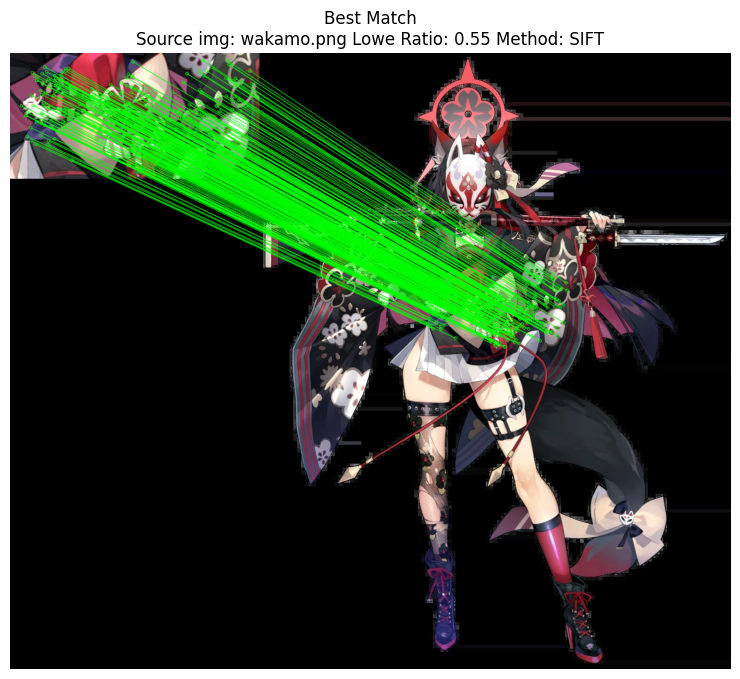


Best Method       : SIFT
Best Lowe Ratio   : 0.55
Best Source Image : wakamo.png
Good Matches      : 261


In [35]:
# show best result
target_rgb = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

if best_matches_data is not None:
    result = cv2.drawMatchesKnn(
        target_rgb,
        best_matches_data['target_kp'],
        best_matches_data['image_data'],
        best_matches_data['keypoint'],
        best_matches_data['match'],
        None,
        matchesMask=best_matches_data['matchesmask'],
        matchColor=[0, 255, 0],
        flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(16,8))
    plt.imshow(result)
    plt.title("Best Match\n" + 
              "Source img: " + best_matches_data['filename'] +
              " Lowe Ratio: " + str(best_ratio) +
              " Method: " + best_method
              )
    plt.axis('off')
    plt.show()

    print("\nBest Method       :", best_method)
    print("Best Lowe Ratio   :", best_ratio)
    print("Best Source Image :", best_matches_data['filename'])
    print("Good Matches      :", best_matches)
else:
    print("Tidak ada matching yang berhasil ditemukan")